In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###EPA Municipal Data

#### Quantitative Analysis for the Dataset using descriptive statistics

In [ ]:
# Load the Excel sheet
file_path = "/content/drive/MyDrive/Projects/IS6051 Business Data Analysis and Visualization/Datasets/01_Waste-Stats-Data-Archive-ALL-Sept-2025.xlsx"
sheet_name = "Municipal Treatment"

data = pd.read_excel(file_path, sheet_name=sheet_name)

In [ ]:
df = pd.DataFrame(data)
df = df.rename(columns={
    "Municipal waste managed (tonnes)": "Managed_tonnes",
    "Municipal waste generated (tonnes)": "Generated_tonnes",
    "Disposal to landfill (tonnes)": "Landfill_tonnes",
    "Energy Recovery (tonnes)": "Energy_Recovery_tonnes",
    "Compost and Anaerobic Digestion (tonnes)": "Organic_tonnes",
    "Materials Recycled excluding compost (tonnes)": "Recycled_excl_compost_tonnes",
    "Total recycled including compost (tonnes)": "Total_Recycled_tonnes",
    "Municipal Waste Generated per capita (kg) rounded, based on CSO population estimates": "Generated_per_capita_kg"
})
df.describe()


,Year,Managed_tonnes,Generated_tonnes,Landfill_tonnes,Energy_Recovery_tonnes,Organic_tonnes,Recycled_excl_compost_tonnes,Total_Recycled_tonnes,Generated_per_capita_kg
count,23.00000,2.100000e+01,1.100000e+01,2.000000e+01,1.300000e+01,20.000000,2.000000e+01,2.000000e+01,11.000000
mean,2012.00000,2.841117e+06,2.916506e+06,1.256743e+06,7.847573e+05,170925.137436,8.379052e+05,1.008830e+06,604.545455
std,6.78233,2.856426e+05,2.127129e+05,6.534203e+05,5.348771e+05,141606.781439,1.833606e+05,2.541381e+05,24.233711
min,2001.00000,2.376072e+06,2.619023e+06,4.180291e+05,8.857400e+04,22000.000000,2.835540e+05,3.055540e+05,560.000000
25%,2006.50000,2.580434e+06,2.765604e+06,5.317228e+05,1.960000e+05,53907.500000,8.277863e+05,9.695348e+05,585.000000
50%,2012.00000,2.824977e+06,2.846115e+06,1.419786e+06,8.808490e+05,131606.000000,8.620860e+05,1.063360e+06,620.000000
75%,2017.50000,3.134840e+06,3.128020e+06,1.849934e+06,1.312957e+06,245696.750000,9.163125e+05,1.132120e+06,620.000000
max,2023.00000,3.299704e+06,3.210220e+06,2.014797e+06,1.412589e+06,487594.000000,1.081147e+06,1.312563e+06,640.000000



=== Central Tendency & Dispersion (Numeric Only) ===
                              count          mean            std  \
Year                           23.0  2.012000e+03       6.782330   
Managed_tonnes                 21.0  2.841117e+06  285642.625589   
Generated_tonnes               11.0  2.916506e+06  212712.868650   
Landfill_tonnes                20.0  1.256743e+06  653420.268394   
Energy_Recovery_tonnes         13.0  7.847573e+05  534877.085474   
Organic_tonnes                 20.0  1.709251e+05  141606.781439   
Recycled_excl_compost_tonnes   20.0  8.379052e+05  183360.627426   
Total_Recycled_tonnes          20.0  1.008830e+06  254138.145215   
Generated_per_capita_kg        11.0  6.045455e+02      24.233711   

                                       min           25%        50%  \
Year                          2.001000e+03  2.006500e+03     2012.0   
Managed_tonnes                2.376072e+06  2.580434e+06  2824977.0   
Generated_tonnes              2.619023e+06  2.765604

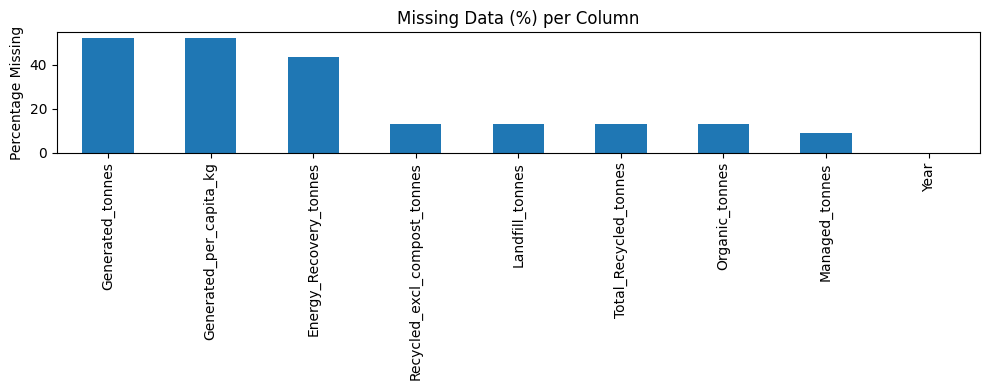


=== Outlier Detection (IQR Rule) ===
                              Outlier Count  Outlier %
Year                                    0.0       0.00
Managed_tonnes                          0.0       0.00
Generated_tonnes                        0.0       0.00
Landfill_tonnes                         0.0       0.00
Energy_Recovery_tonnes                  0.0       0.00
Organic_tonnes                          0.0       0.00
Recycled_excl_compost_tonnes            5.0      21.74
Total_Recycled_tonnes                   2.0       8.70
Generated_per_capita_kg                 0.0       0.00


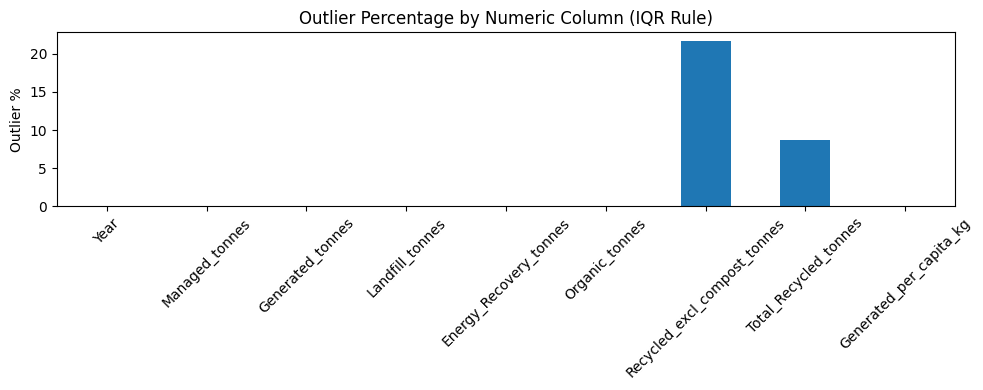

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# BASIC DESCRIPTIVE STATS
print("\n=== Central Tendency & Dispersion (Numeric Only) ===")
print(df.describe().T)


# ---------------------------------------------------------
# 1. Rename columns (same as before)
# ---------------------------------------------------------

df = df.rename(columns={
    "Municipal waste managed (tonnes)": "Managed_tonnes",
    "Municipal waste generated (tonnes)": "Generated_tonnes",
    "Disposal to landfill (tonnes)": "Landfill_tonnes",
    "Energy Recovery (tonnes)": "Energy_Recovery_tonnes",
    "Compost and Anaerobic Digestion (tonnes)": "Organic_tonnes",
    "Materials Recycled excluding compost (tonnes)": "Recycled_excl_compost_tonnes",
    "Total recycled including compost (tonnes)": "Total_Recycled_tonnes",
    "Municipal Waste Generated per capita (kg) rounded, based on CSO population estimates": "Generated_per_capita_kg"
})

# ===== MISSINGNESS =====

missing_pct = df.isna().mean() * 100

print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### DATASET REFINING FOR VISUALIZATION

In [ ]:
# Ensure Year is numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Drop completely empty rows & set Year as index
df = df[~df.isna().all(axis=1)]
df = df.set_index("Year").sort_index()

# Linear interpolation for numeric waste metrics
cols_to_interp = [
    "Managed_tonnes", "Generated_tonnes", "Landfill_tonnes",
    "Energy_Recovery_tonnes", "Organic_tonnes",
    "Recycled_excl_compost_tonnes", "Total_Recycled_tonnes",
    "Generated_per_capita_kg"
]

df[cols_to_interp] = df[cols_to_interp].interpolate(
    method="linear",
    limit_direction="both"
)

# Recompute KPIs safely
def safe_div(a, b):
    return np.where((b == 0) | (b.isna()), np.nan, a / b)

df["Recycling_Rate_%"] = safe_div(df["Total_Recycled_tonnes"], df["Generated_tonnes"]) * 100
df["Landfill_Rate_%"] = safe_div(df["Landfill_tonnes"], df["Generated_tonnes"]) * 100
df["Organic_Diversion_Rate_%"] = safe_div(df["Organic_tonnes"], df["Generated_tonnes"]) * 100
df["Energy_Recovery_Rate_%"] = safe_div(df["Energy_Recovery_tonnes"], df["Generated_tonnes"]) * 100

# Reset index for clean output
df = df.reset_index()

df

,Year,Managed_tonnes,Generated_tonnes,Landfill_tonnes,Energy_Recovery_tonnes,Organic_tonnes,Recycled_excl_compost_tonnes,Total_Recycled_tonnes,Generated_per_capita_kg,Recycling_Rate_%,Landfill_Rate_%,Organic_Diversion_Rate_%,Energy_Recovery_Rate_%
0,2001,2.376072e+06,2.846115e+06,1.992050e+06,8.857400e+04,22000.000000,2.835540e+05,3.055540e+05,620.0,10.735828,69.991901,0.772984,3.112102
1,2002,2.471617e+06,2.846115e+06,1.901864e+06,8.857400e+04,34000.000000,4.629050e+05,4.969050e+05,620.0,17.459063,66.823161,1.194611,3.112102
2,2003,2.630592e+06,2.846115e+06,1.832624e+06,8.857400e+04,40000.000000,6.867630e+05,7.267630e+05,620.0,25.535265,64.390371,1.405425,3.112102
3,2004,2.773264e+06,2.846115e+06,1.818536e+06,8.857400e+04,49580.000000,8.354880e+05,8.850680e+05,620.0,31.097408,63.895380,1.742024,3.112102
4,2005,2.837774e+06,2.846115e+06,1.824066e+06,8.857400e+04,47800.000000,8.762270e+05,9.240270e+05,620.0,32.466257,64.089680,1.679482,3.112102
5,2006,3.209132e+06,2.846115e+06,1.980618e+06,8.857400e+04,55350.000000,1.064342e+06,1.119692e+06,620.0,39.341067,69.590231,1.944756,3.112102
6,2007,3.299704e+06,2.846115e+06,2.014797e+06,8.857400e+04,78620.000000,1.081147e+06,1.159767e+06,620.0,40.749126,70.791131,2.762362,3.112102
7,2008,3.103820e+06,2.846115e+06,1.938712e+06,8.857400e+04,106670.000000,9.768620e+05,1.083532e+06,620.0,38.070563,68.117838,3.747916,3.112102
8,2009,2.824977e+06,2.846115e+06,1.723705e+06,1.110000e+05,88100.000000,9.022220e+05,9.903220e+05,620.0,34.795572,60.563435,3.095448,3.900053
9,2010,2.580434e+06,2.846115e+06,1.495565e+06,1.090000e+05,107000.000000,9.100000e+05,1.017000e+06,620.0,35.732920,52.547596,3.759511,3.829782


Missing Percentage 
  Year                            0.0
Managed_tonnes                  0.0
Generated_tonnes                0.0
Landfill_tonnes                 0.0
Energy_Recovery_tonnes          0.0
Organic_tonnes                  0.0
Recycled_excl_compost_tonnes    0.0
Total_Recycled_tonnes           0.0
Generated_per_capita_kg         0.0
Recycling_Rate_%                0.0
Landfill_Rate_%                 0.0
Organic_Diversion_Rate_%        0.0
Energy_Recovery_Rate_%          0.0
dtype: float64


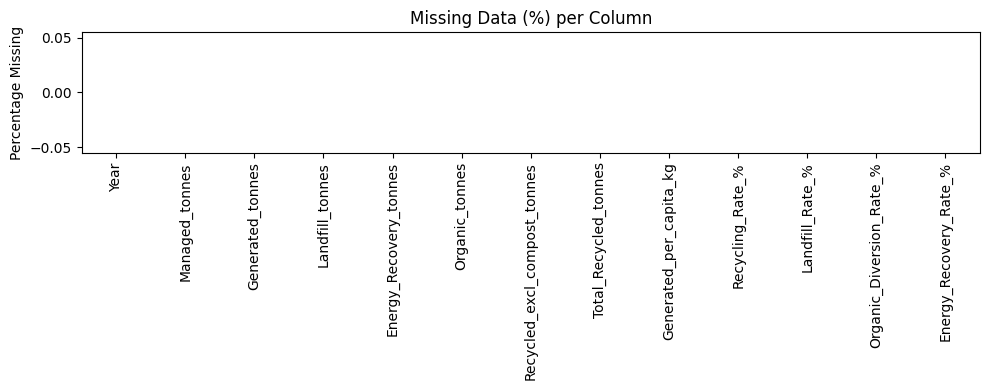


=== Outlier Detection (IQR Rule) ===
                              Outlier Count  Outlier %
Year                                    0.0       0.00
Managed_tonnes                          0.0       0.00
Generated_tonnes                        7.0      30.43
Landfill_tonnes                         0.0       0.00
Energy_Recovery_tonnes                  0.0       0.00
Organic_tonnes                          0.0       0.00
Recycled_excl_compost_tonnes            5.0      21.74
Total_Recycled_tonnes                   3.0      13.04
Generated_per_capita_kg                 0.0       0.00
Recycling_Rate_%                        3.0      13.04
Landfill_Rate_%                         0.0       0.00
Organic_Diversion_Rate_%                0.0       0.00
Energy_Recovery_Rate_%                  0.0       0.00


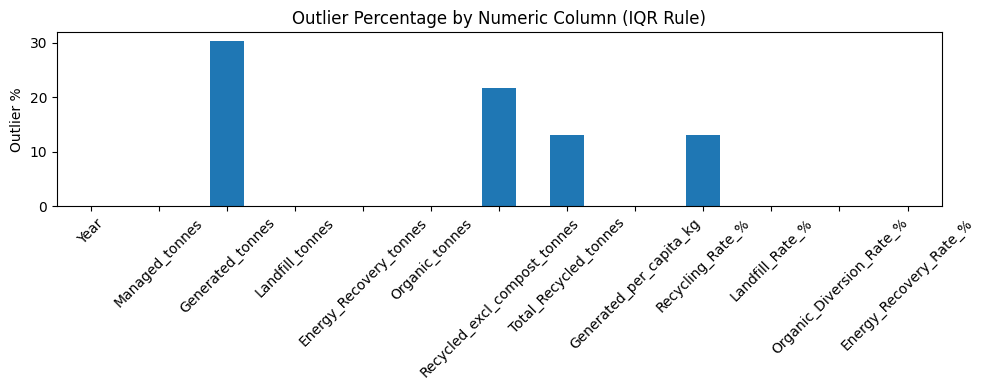

In [ ]:
# ===== MISSINGNESS =====

missing_pct = df.isna().mean() * 100

print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.to_excel("Municipal_Treatment_Cleaned.xlsx", index=False)


In [ ]:
df

,Year,Managed_tonnes,Generated_tonnes,Landfill_tonnes,Energy_Recovery_tonnes,Organic_tonnes,Recycled_excl_compost_tonnes,Total_Recycled_tonnes,Generated_per_capita_kg,Recycling_Rate_%,Landfill_Rate_%,Organic_Diversion_Rate_%,Energy_Recovery_Rate_%
0,2001,2.376072e+06,2.846115e+06,1.992050e+06,8.857400e+04,22000.000000,2.835540e+05,3.055540e+05,620.0,10.735828,69.991901,0.772984,3.112102
1,2002,2.471617e+06,2.846115e+06,1.901864e+06,8.857400e+04,34000.000000,4.629050e+05,4.969050e+05,620.0,17.459063,66.823161,1.194611,3.112102
2,2003,2.630592e+06,2.846115e+06,1.832624e+06,8.857400e+04,40000.000000,6.867630e+05,7.267630e+05,620.0,25.535265,64.390371,1.405425,3.112102
3,2004,2.773264e+06,2.846115e+06,1.818536e+06,8.857400e+04,49580.000000,8.354880e+05,8.850680e+05,620.0,31.097408,63.895380,1.742024,3.112102
4,2005,2.837774e+06,2.846115e+06,1.824066e+06,8.857400e+04,47800.000000,8.762270e+05,9.240270e+05,620.0,32.466257,64.089680,1.679482,3.112102
5,2006,3.209132e+06,2.846115e+06,1.980618e+06,8.857400e+04,55350.000000,1.064342e+06,1.119692e+06,620.0,39.341067,69.590231,1.944756,3.112102
6,2007,3.299704e+06,2.846115e+06,2.014797e+06,8.857400e+04,78620.000000,1.081147e+06,1.159767e+06,620.0,40.749126,70.791131,2.762362,3.112102
7,2008,3.103820e+06,2.846115e+06,1.938712e+06,8.857400e+04,106670.000000,9.768620e+05,1.083532e+06,620.0,38.070563,68.117838,3.747916,3.112102
8,2009,2.824977e+06,2.846115e+06,1.723705e+06,1.110000e+05,88100.000000,9.022220e+05,9.903220e+05,620.0,34.795572,60.563435,3.095448,3.900053
9,2010,2.580434e+06,2.846115e+06,1.495565e+06,1.090000e+05,107000.000000,9.100000e+05,1.017000e+06,620.0,35.732920,52.547596,3.759511,3.829782


###EPA - Household Data

In [ ]:
sheet_name = "Household"
data2 = pd.read_excel(file_path, sheet_name=sheet_name)
df2=pd.DataFrame(data2)
df2 = df2.rename(columns={
    "Est. total generated household waste (tonnes)": "Generated_tonnes",
    "Est. unmanaged household waste (tonnes)": "Unmanaged_tonnes",
    "Household waste managed (tonnes)": "Managed_tonnes",
    "Household waste per capita (kg/person)": "PerCapita_kg",
    "General Waste collected - black bin (t)": "BlackBin_tonnes",
    "Mixed dry recyclables collected - green or blue bin(t)": "Recyclables_tonnes",
    "Organic waste collected - brown bin (t)": "Organic_tonnes"
})

df2["Year"] = pd.to_numeric(df2["Year"], errors="coerce")

In [ ]:
df2

,Year,Generated_tonnes,Unmanaged_tonnes,Managed_tonnes,PerCapita_kg,BlackBin_tonnes,Recyclables_tonnes,Organic_tonnes
0,2010,NaN,NaN,1.420706e+06,311.914025,NaN,NaN,NaN
1,2011,NaN,NaN,1.406576e+06,307.455026,NaN,NaN,NaN
2,2012,NaN,NaN,1.362900e+06,296.688944,NaN,NaN,NaN
3,2013,NaN,NaN,1.398156e+06,302.978742,NaN,NaN,NaN
4,2014,NaN,NaN,1.426123e+06,306.996814,NaN,NaN,NaN
5,2015,NaN,NaN,1.416444e+06,302.155382,700910.918,254253.87,102003.254
6,2016,NaN,NaN,1.450727e+06,306.086379,681026.500,253328.36,112463.890
7,2017,NaN,NaN,1.495210e+06,310.796317,661100.910,253657.86,129081.180
8,2018,1576197.000,47307.0,1.528890e+06,312.982866,675763.790,249227.17,137031.870
9,2019,1622008.000,48660.0,1.573348e+06,317.303217,634824.620,243547.83,159384.730


In [ ]:
df2.describe()

,Year,Generated_tonnes,Unmanaged_tonnes,Managed_tonnes,PerCapita_kg,BlackBin_tonnes,Recyclables_tonnes,Organic_tonnes
count,13.00000,5.000000e+00,5.000000,1.300000e+01,13.000000,8.00000,8.000000,8.000000
mean,2016.00000,1.744282e+06,38067.400000,1.531378e+06,318.543685,685995.16600,255257.636250,155753.060500
std,3.89444,1.368614e+05,9902.954549,1.693440e+05,22.325880,28775.97361,7651.492475,41969.162226
min,2010.00000,1.576197e+06,25700.000000,1.362900e+06,296.688944,634824.62000,243547.830000,102003.254000
25%,2013.00000,1.622008e+06,31700.000000,1.416444e+06,306.086379,672098.07000,252303.062500,124926.857500
50%,2016.00000,1.800592e+06,36970.000000,1.450727e+06,310.796317,690493.79500,253955.865000,148208.300000
75%,2019.00000,1.837215e+06,47307.000000,1.573348e+06,317.303217,703548.93850,258372.395000,198094.180000
max,2022.00000,1.885397e+06,48660.000000,1.853697e+06,368.535467,722910.50000,267590.420000,208718.840000


Missing Percentage 
  Year                   0.000000
Generated_tonnes      61.538462
Unmanaged_tonnes      61.538462
Managed_tonnes         0.000000
PerCapita_kg           0.000000
BlackBin_tonnes       38.461538
Recyclables_tonnes    38.461538
Organic_tonnes        38.461538
dtype: float64


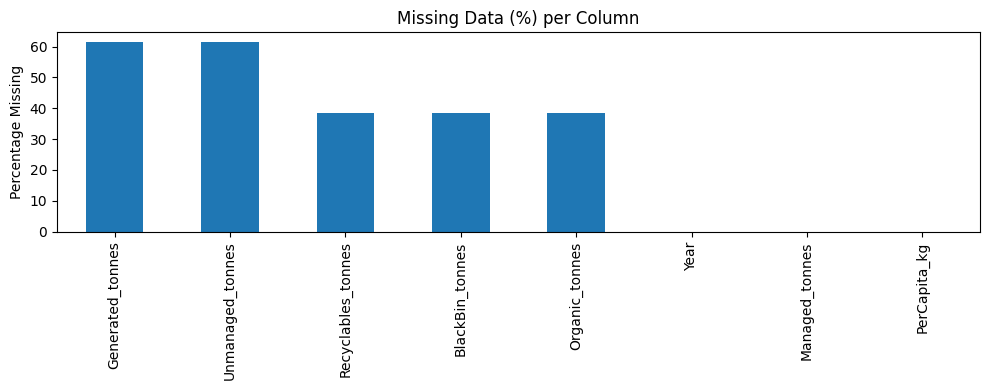


=== Outlier Detection (IQR Rule) ===
                    Outlier Count  Outlier %
Year                          0.0       0.00
Generated_tonnes              0.0       0.00
Unmanaged_tonnes              0.0       0.00
Managed_tonnes                2.0      15.38
PerCapita_kg                  3.0      23.08
BlackBin_tonnes               0.0       0.00
Recyclables_tonnes            1.0       7.69
Organic_tonnes                0.0       0.00


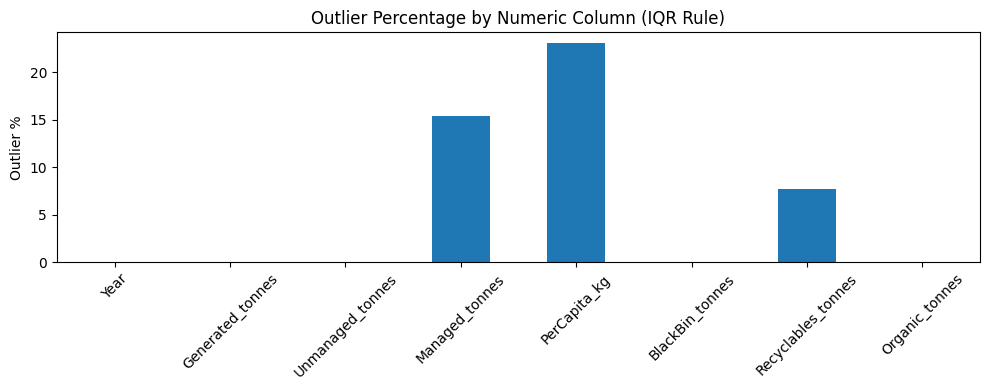

In [ ]:
# ===== MISSINGNESS =====

missing_pct = df2.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df2.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df2))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Generated = Managed + Unmanaged


In [ ]:
# -----------------------------------------------------
#  Estimate Generated and Unmanaged where missing
# -----------------------------------------------------

# Case 1: Generated missing but Managed exists → infer unmanaged = 0 initially
df2.loc[df2["Generated_tonnes"].isna() & df2["Managed_tonnes"].notna(),
       "Generated_tonnes"] = df2["Managed_tonnes"]

# Case 2: Unmanaged missing but Generated & Managed exist → calculate directly
df2.loc[df2["Unmanaged_tonnes"].isna() &
       df2["Generated_tonnes"].notna() &
       df2["Managed_tonnes"].notna(),
       "Unmanaged_tonnes"] = df2["Generated_tonnes"] - df2["Managed_tonnes"]

# If Generated exists but Managed is missing → backfill managed using average ratio
managed_ratio = (df2["Managed_tonnes"] / df2["Generated_tonnes"]).dropna().mean()

df2.loc[df2["Managed_tonnes"].isna() & df2["Generated_tonnes"].notna(),
       "Managed_tonnes"] = df2["Generated_tonnes"] * managed_ratio

# Recompute unmanaged cleanly
df2["Unmanaged_tonnes"] = df2["Generated_tonnes"] - df2["Managed_tonnes"]
bin_cols = ["BlackBin_tonnes", "Recyclables_tonnes", "Organic_tonnes"]

# Ensure DataFrame is sorted by Year
df2 = df2.sort_values('Year').reset_index(drop=True)

# Interpolate each bin column linearly over time
for col in bin_cols:
    # Use linear interpolation based on Year
    df2[col] = df2[col].interpolate(method='linear', limit_direction='both')

# Post-imputation check
# (Useful if interpolation causes slight over/under-allocation)
df2["Bins_Total"] = df2[bin_cols].sum(axis=1)
scaling_factor = df2["Managed_tonnes"] / df2["Bins_Total"]
# Only adjust where bins are non-zero and scaling is meaningful
adjust_mask = (df2["Bins_Total"] > 0) & (scaling_factor.notna())
if adjust_mask.any():
    for col in bin_cols:
        df2.loc[adjust_mask, col] = df2.loc[adjust_mask, col] * scaling_factor[adjust_mask]

# Drop helper column
df2 = df2.drop(columns=["Bins_Total"])

In [ ]:
df2

,Year,Generated_tonnes,Unmanaged_tonnes,Managed_tonnes,PerCapita_kg,BlackBin_tonnes,Recyclables_tonnes,Organic_tonnes
0,2010,1420706.000,0.00000,1.420706e+06,311.914025,9.419395e+05,341686.453129,137080.037629
1,2011,1406576.000,0.00000,1.406576e+06,307.455026,9.325712e+05,338288.121889,135716.672561
2,2012,1362900.000,0.00000,1.362900e+06,296.688944,9.036137e+05,327783.839140,131502.494735
3,2013,1398156.000,0.00000,1.398156e+06,302.978742,9.269887e+05,336263.072417,134904.249782
4,2014,1426123.000,0.00000,1.426123e+06,306.996814,9.455310e+05,342989.267023,137602.709148
5,2015,1416444.000,0.00000,1.416444e+06,302.155382,9.391138e+05,340661.422149,136668.808901
6,2016,1450727.000,0.00000,1.450727e+06,306.086379,9.437962e+05,351073.470663,155857.355199
7,2017,1495210.000,0.00000,1.495210e+06,310.796317,9.469696e+05,363342.837042,184897.570885
8,2018,1576197.000,47307.00000,1.528890e+06,312.982866,9.728308e+05,358787.887772,197271.329586
9,2019,1622008.000,48660.00000,1.573348e+06,317.303217,9.624603e+05,369243.883463,241643.855623


Missing Percentage 
  Year                  0.0
Generated_tonnes      0.0
Unmanaged_tonnes      0.0
Managed_tonnes        0.0
PerCapita_kg          0.0
BlackBin_tonnes       0.0
Recyclables_tonnes    0.0
Organic_tonnes        0.0
dtype: float64


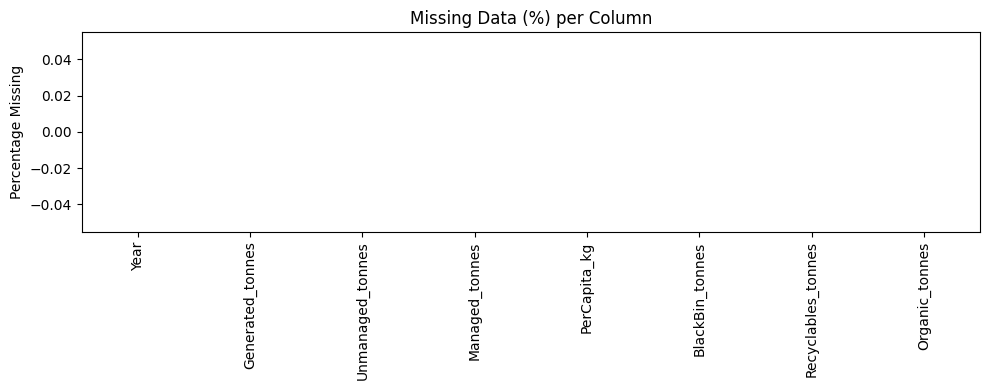


=== Outlier Detection (IQR Rule) ===
                    Outlier Count  Outlier %
Year                          0.0       0.00
Generated_tonnes              0.0       0.00
Unmanaged_tonnes              0.0       0.00
Managed_tonnes                2.0      15.38
PerCapita_kg                  3.0      23.08
BlackBin_tonnes               3.0      23.08
Recyclables_tonnes            1.0       7.69
Organic_tonnes                0.0       0.00


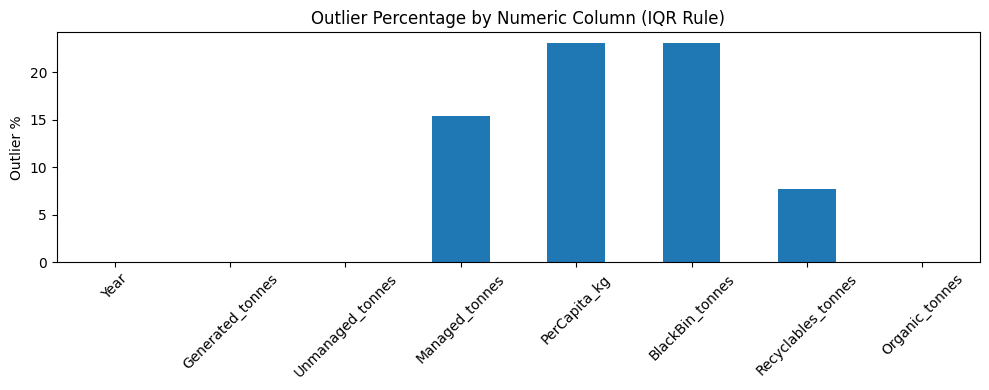

In [ ]:
# ===== MISSINGNESS =====

missing_pct = df2.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df2.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df2))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###EPA Compost and Anaerobic Digestion



In [ ]:
sheet_name = "Comp & Anaerobic Digestion"
data3 = pd.read_excel(file_path, sheet_name=sheet_name)


In [ ]:
data3.head()

,Year,"Municipal bio-waste (kitchen and canteen food waste, garden and park green waste, edible oils and fats) accepted for composting/anaerobic digestion in Ireland (tonnes)",total tonnage collected for compost in Ireland*,wet tonnage collected for compost in Ireland,tonnage collected for compost in Ireland - EU submission**,total tonnage collected for anaerobic digestion in Ireland*,wet tonnage collected for anaerobic digestion in Ireland,tonnage collected for anaerobic digestion in Ireland - EU submission**,Total tonnage compost + anaerobic digestion in Ireland*,Total wet tonnage compost + anaerobic digestion in Ireland,tonnage compost + anaerobic digestion in Ireland - EU submission**
0,2005,48000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,55000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007,79000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,107000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009,88000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
column_mapping = {
    'Year': 'Year',
    'Municipal bio-waste (kitchen and canteen food waste, garden and park green waste, edible oils and fats) accepted for composting/anaerobic digestion in Ireland (tonnes)': 'Bio_waste_accepted_t',
    'total tonnage collected for compost in Ireland*': 'Compost_collected_t',
    'wet tonnage collected for compost in Ireland ': 'Compost_wet_t',
    'tonnage collected for compost in Ireland - EU submission**': 'Compost_EU_t',
    'total tonnage collected for anaerobic digestion in Ireland*': 'AD_collected_t',
    'wet tonnage collected for anaerobic digestion in Ireland': 'AD_wet_t',
    'tonnage collected for anaerobic digestion in Ireland - EU submission**': 'AD_EU_t',
    'Total tonnage compost + anaerobic digestion in Ireland*': 'Total_collected_t',
    'Total wet tonnage compost + anaerobic digestion in Ireland': 'Total_wet_t',
    'tonnage compost + anaerobic digestion in Ireland - EU submission**': 'Total_EU_t'
}

# Rename the columns
data3 = data3.rename(columns=column_mapping)

In [ ]:
data3.describe()

,Bio_waste_accepted_t,Compost_collected_t,Compost_wet_t,Compost_EU_t,AD_collected_t,AD_wet_t,AD_EU_t,Total_collected_t,Total_wet_t,Total_EU_t
count,18.000000,5.000000,1.0,1.0,5.000000,1.0,1.0,5.000000,1.0,1.0
mean,184777.777778,283930.000000,306801.0,251805.0,229568.400000,428703.0,257767.0,513498.400000,735504.0,509572.0
std,94421.181295,10310.950344,NaN,NaN,81050.036202,NaN,NaN,88287.571839,NaN,NaN
min,48000.000000,267205.000000,306801.0,251805.0,120397.000000,428703.0,257767.0,401324.000000,735504.0,509572.0
25%,107000.000000,280927.000000,306801.0,251805.0,178136.000000,428703.0,257767.0,445341.000000,735504.0,509572.0
50%,169000.000000,288695.000000,306801.0,251805.0,237637.000000,428703.0,257767.0,528082.000000,735504.0,509572.0
75%,254250.000000,290445.000000,306801.0,251805.0,303176.000000,428703.0,257767.0,595554.000000,735504.0,509572.0
max,334000.000000,292378.000000,306801.0,251805.0,308496.000000,428703.0,257767.0,597191.000000,735504.0,509572.0


Missing Percentage 
  Year                     9.090909
Bio_waste_accepted_t    18.181818
Compost_collected_t     77.272727
Compost_wet_t           95.454545
Compost_EU_t            95.454545
AD_collected_t          77.272727
AD_wet_t                95.454545
AD_EU_t                 95.454545
Total_collected_t       77.272727
Total_wet_t             95.454545
Total_EU_t              95.454545
dtype: float64


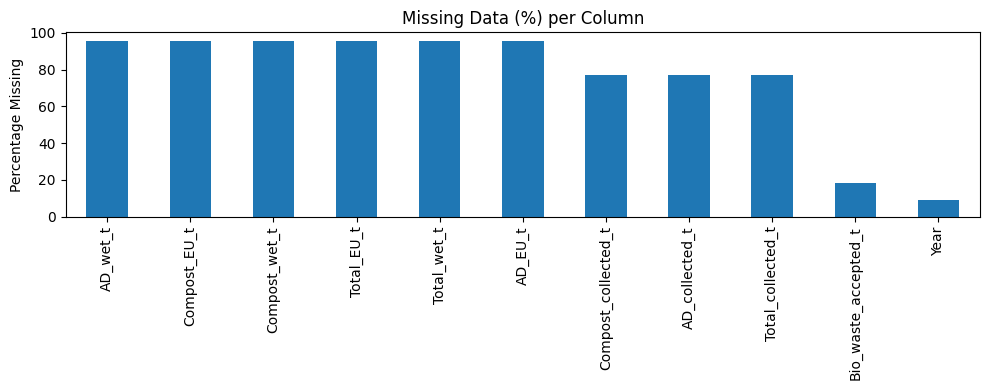


=== Outlier Detection (IQR Rule) ===
                      Outlier Count  Outlier %
Bio_waste_accepted_t            0.0        0.0
Compost_collected_t             0.0        0.0
Compost_wet_t                   0.0        0.0
Compost_EU_t                    0.0        0.0
AD_collected_t                  0.0        0.0
AD_wet_t                        0.0        0.0
AD_EU_t                         0.0        0.0
Total_collected_t               0.0        0.0
Total_wet_t                     0.0        0.0
Total_EU_t                      0.0        0.0


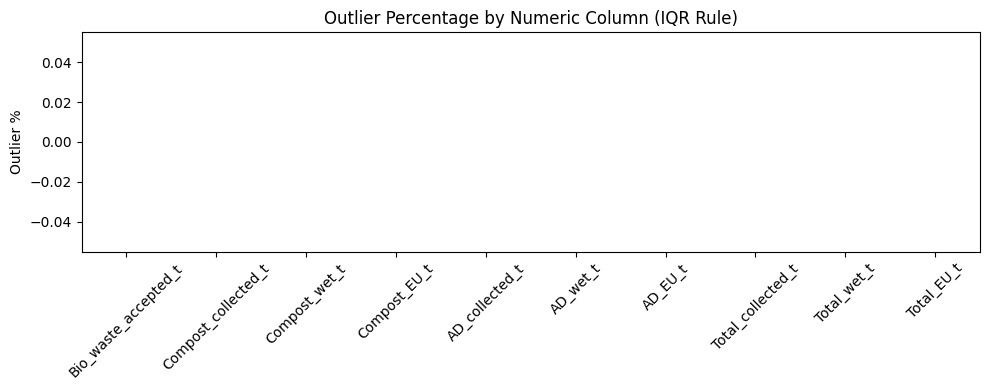

In [ ]:
import matplotlib.pyplot as plt

# ===== MISSINGNESS =====

missing_pct = data3.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = data3.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(data3))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Actual column names in df:")
print(data3.columns.tolist())

Actual column names in df:
['Year', 'Bio_waste_accepted_t', 'Compost_collected_t', 'Compost_wet_t', 'Compost_EU_t', 'AD_collected_t', 'AD_wet_t', 'AD_EU_t', 'Total_collected_t', 'Total_wet_t', 'Total_EU_t']


In [ ]:
# Keeping only the required columns
df_clean = data3[['Year', 'Bio_waste_accepted_t', 'Compost_collected_t']].copy()

# Converting 'Year' to numeric (coerce errors to NaN, then drop if any)
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')

# Drop rows where Year became NaN (if any malformed entries)
df_clean = df_clean.dropna(subset=['Year']).reset_index(drop=True)

# Ensure Year is integer (optional, for clean display)
df_clean['Year'] = df_clean['Year'].astype(int)

# Sort by Year (now safe!)
df_clean = df_clean.sort_values('Year').reset_index(drop=True)

# Interpolate missing values in the two data columns
df_clean['Bio_waste_accepted_t'] = df_clean['Bio_waste_accepted_t'].interpolate(
    method='linear', limit_direction='both'
)
df_clean['Compost_collected_t'] = df_clean['Compost_collected_t'].interpolate(
    method='linear', limit_direction='both'
)

# Final safety fill (in case of leading/trailing NaNs that interpolation couldn't handle)
df_clean = df_clean.ffill().bfill()

# Check result
print("Missing % after cleaning:")
print(df_clean.isnull().mean() * 100)
print("\nData types:")
print(df_clean.dtypes)

Missing % after cleaning:
Year                    0.0
Bio_waste_accepted_t    0.0
Compost_collected_t     0.0
dtype: float64

Data types:
Year                      int64
Bio_waste_accepted_t    float64
Compost_collected_t     float64
dtype: object


Missing Percentage 
  Year                    0.0
Bio_waste_accepted_t    0.0
Compost_collected_t     0.0
dtype: float64


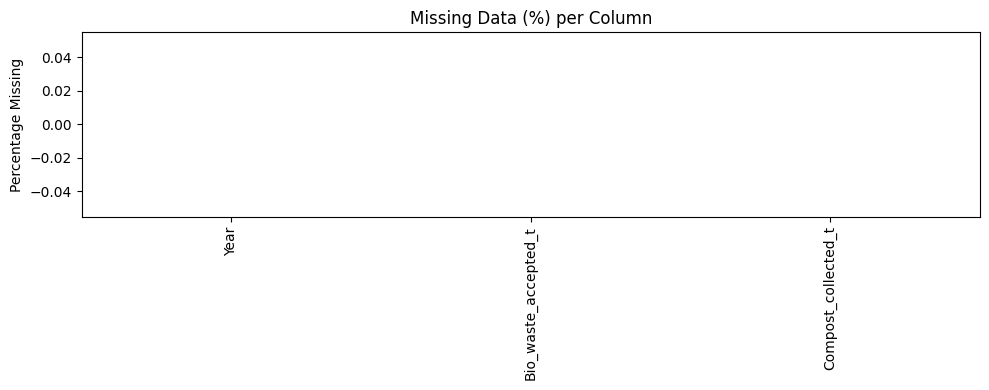


=== Outlier Detection (IQR Rule) ===
                      Outlier Count  Outlier %
Year                            0.0       0.00
Bio_waste_accepted_t            0.0       0.00
Compost_collected_t             5.0      27.78


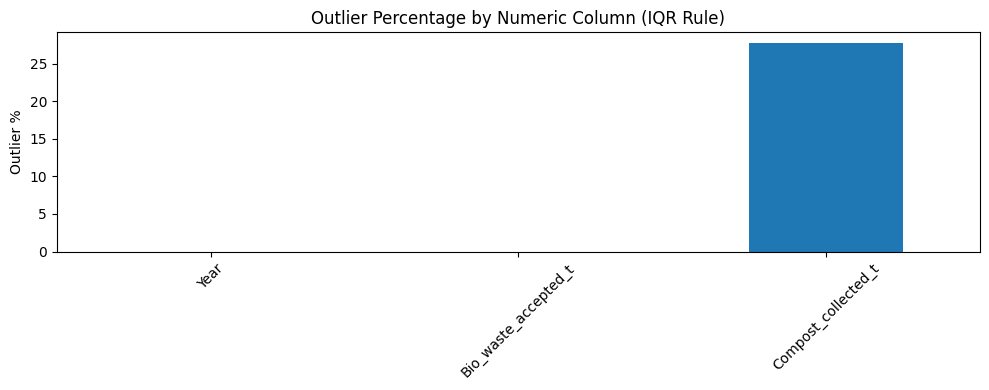

In [ ]:
# ===== MISSINGNESS =====

missing_pct = df_clean.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df_clean.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df_clean))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#df_clean.to_excel("Compost_Anaerobic_Cleaned.xlsx", index=False)

### EPA Food Waste

In [ ]:
sheet_name = "Food Waste"
data4 = pd.read_excel(file_path, sheet_name=sheet_name)
data4.head()
# Printing the original column names
print("Original column names:")
for i, col in enumerate(data4.columns):
    print(f"{i}: '{col}'")


expected_count = 7
if len(data4.columns) == expected_count:
    data4 = data4.copy()
else:
    data4 = data4.iloc[:, :7].copy()

print("\nColumns in data4:")
print(data4.columns.tolist())

Original column names:
0: 'Year'
1: 'Total (t)'
2: 'Primary Production (t)'
3: 'Process and Manufacturing (t)'
4: 'Retail and Distribution (t)'
5: 'Restaurants and Food Service (t)'
6: 'Households (t)'

Columns in data4:
['Year', 'Total (t)', 'Primary Production (t)', 'Process and Manufacturing (t)', 'Retail and Distribution (t)', 'Restaurants and Food Service (t)', 'Households (t)']


In [ ]:
data4.describe()

,Year,Total (t),Primary Production (t),Process and Manufacturing (t),Retail and Distribution (t),Restaurants and Food Service (t),Households (t)
count,6.000000,6.000000e+00,4.000000,6.000000,6.00000,6.000000,6.000000
mean,2020.500000,8.768702e+05,56567.250000,327444.833333,86751.00000,189903.833333,235059.000000
std,1.870829,1.586260e+05,9321.918664,135713.031124,17940.82745,27512.614346,16405.813019
min,2018.000000,7.492430e+05,50032.000000,215000.000000,60900.00000,157045.000000,220158.000000
25%,2019.250000,7.573250e+05,52135.750000,222150.000000,77201.50000,175911.000000,220963.250000
50%,2020.500000,8.026290e+05,52918.500000,267610.500000,86454.50000,183750.000000,231000.000000
75%,2021.750000,9.990145e+05,57350.000000,449366.250000,97575.75000,199725.000000,249625.000000
max,2023.000000,1.100020e+06,70400.000000,497500.000000,111297.00000,236530.000000,254745.000000


Missing Percentage 
  Year                                 0.000000
Total (t)                            0.000000
Primary Production (t)              33.333333
Process and Manufacturing (t)        0.000000
Retail and Distribution (t)          0.000000
Restaurants and Food Service (t)     0.000000
Households (t)                       0.000000
dtype: float64


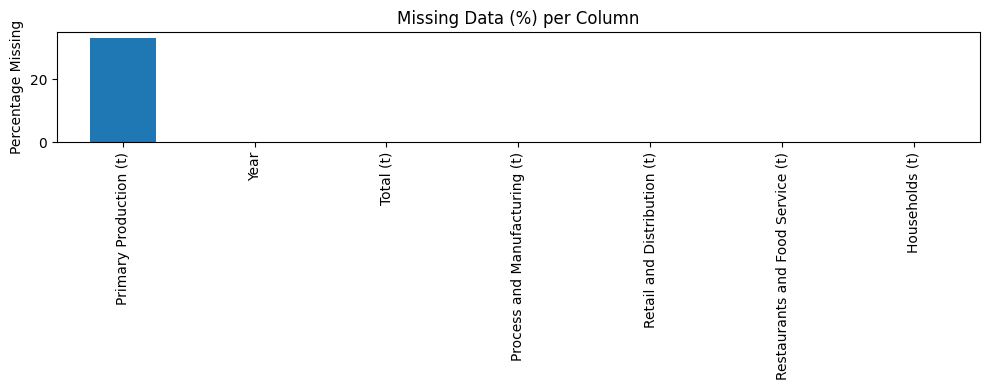


=== Outlier Detection (IQR Rule) ===
                                  Outlier Count  Outlier %
Year                                        0.0       0.00
Total (t)                                   0.0       0.00
Primary Production (t)                      1.0      16.67
Process and Manufacturing (t)               0.0       0.00
Retail and Distribution (t)                 0.0       0.00
Restaurants and Food Service (t)            1.0      16.67
Households (t)                              0.0       0.00


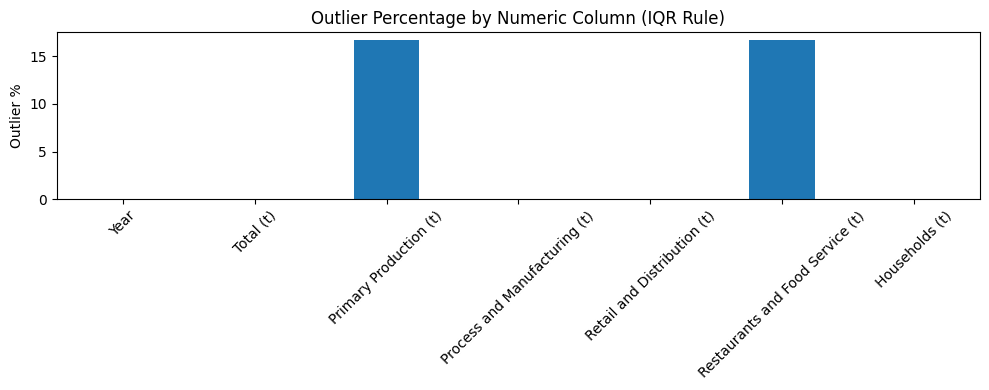

In [ ]:
# ===== MISSINGNESS =====

missing_pct = data4.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = data4.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(data4))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Step 1: Creating 'Commercial' = sum of 4 upstream sectors
upstream_cols = [
    'Primary Production (t)',
    'Process and Manufacturing (t)',
    'Retail and Distribution (t)',
    'Restaurants and Food Service (t)'
]

# Fill NaN with 0 before summing (since missing likely means unreported, not negative)
data4['Commercial'] = data4[upstream_cols].fillna(0).sum(axis=1)

# Step 2: Create new simplified DataFrame
df_simple = data4[['Year', 'Total (t)', 'Commercial', 'Households (t)']].copy()

# Step 3: Add missing years 2015, 2016, 2017
future_years = pd.DataFrame({'Year': [2015, 2016, 2017]})
df_full = pd.concat([future_years, df_simple], ignore_index=True).sort_values('Year').reset_index(drop=True)

# Step 4: Backward fill (i.e., fill 2015-2017 with 2018 values)
df_full['Total (t)'] = df_full['Total (t)'].bfill()
df_full['Commercial'] = df_full['Commercial'].bfill()
df_full['Households (t)'] = df_full['Households (t)'].bfill()

# Step 5: Clean up final column names
df_final = df_full.rename(columns={
    'Total (t)': 'Total_t',
    'Households (t)': 'Households_t'
})

# Ensure no NaN remains
df_final = df_final.ffill()

print(df_final)


# Reorder columns for clarity
df_long = df_long[['Year', 'Total_t', 'Sector', 'Value_tonnes']].reset_index(drop=True)


   Year    Total_t  Commercial  Households_t
0  2015  1053700.0    801200.0      252500.0
1  2016  1053700.0    801200.0      252500.0
2  2017  1053700.0    801200.0      252500.0
3  2018  1053700.0    801200.0      252500.0
4  2019  1100020.0    845275.0      254745.0
5  2020   770300.0    529300.0      241000.0
6  2021   753000.0    532000.0      221000.0
7  2022   749243.0    529085.0      220158.0
8  2023   834958.0    614007.0      220951.0


NameError: name 'df_long' is not defined

In [ ]:
df_final.to_excel("Food_Waste_Data.xlsx")

### EEA GHG Data

In [ ]:
EEAdata = pd.read_csv("/content/drive/MyDrive/Projects/IS6051 Business Data Analysis and Visualization/Datasets/UNFCCC_v28.csv")

In [ ]:
EEAdata.head()

,Country_code,Country,Format_name,Pollutant_name,Sector_code,Sector_name,Parent_sector_code,Unit,Year,emissions,Notation,PublicationDate,DataSource,Country_code_3
0,CZ,Czechia,IPCC Common Reporting Format,N₂O,4.B.2,4.B.2 - Land converted to cropland,4.B,Gg,1997,0.01785,NaN,20250315,EEA,CZE
1,CZ,Czechia,IPCC Common Reporting Format,N₂O,4.B.2,4.B.2 - Land converted to cropland,4.B,Gg,1998,0.02272,NaN,20250315,EEA,CZE
2,CZ,Czechia,IPCC Common Reporting Format,N₂O,4.B.2,4.B.2 - Land converted to cropland,4.B,Gg,2011,0.01940,NaN,20250315,EEA,CZE
3,CZ,Czechia,IPCC Common Reporting Format,N₂O,4.B.2,4.B.2 - Land converted to cropland,4.B,Gg,2018,0.00927,NaN,20250315,EEA,CZE
4,CZ,Czechia,IPCC Common Reporting Format,N₂O,4.C,4.C - Grassland,4,Gg,2001,NaN,NO,20250315,EEA,CZE


In [ ]:
EEAdata.describe()

,Year,emissions,PublicationDate
count,629220.000000,3.821440e+05,629220.0
mean,2006.495218,8.259723e+03,20250315.0
std,9.808253,1.028086e+05,0.0
min,1990.000000,-4.698874e+05,20250315.0
25%,1998.000000,1.859800e-01,20250315.0
50%,2006.000000,1.935670e+01,20250315.0
75%,2015.000000,6.082974e+02,20250315.0
max,2023.000000,4.872571e+06,20250315.0


Missing Percentage 
  Country_code           0.000000
Country                0.000000
Format_name            0.000000
Pollutant_name         0.000000
Sector_code            0.000000
Sector_name            0.000000
Parent_sector_code     3.014844
Unit                   0.000000
Year                   0.000000
emissions             39.267029
Notation              63.909126
PublicationDate        0.000000
DataSource             0.000000
Country_code_3         0.000000
dtype: float64


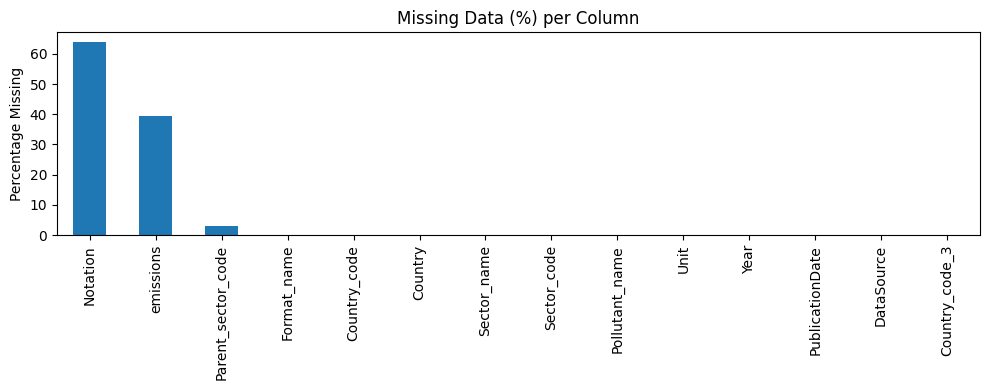


=== Outlier Detection (IQR Rule) ===
                 Outlier Count  Outlier %
Year                       0.0       0.00
emissions              77457.0      12.31
PublicationDate            0.0       0.00


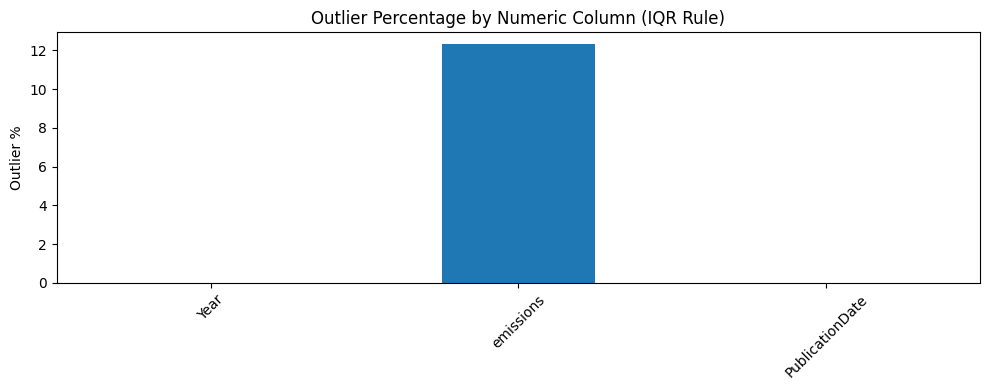

In [ ]:
# ===== MISSINGNESS =====

missing_pct = EEAdata.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = EEAdata.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(EEAdata))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Filter for Ireland
ireland_filter = (
    (EEAdata['Country'] == 'Ireland') |
    (EEAdata['Country_code'] == 'IE') |
    (EEAdata['Country_code_3'] == 'IRL')
)

# Define the sectors of interest
main_sectors = [
    "6 - Other Sector",
    "5 - Waste management",
    "4 - Land Use, Land-Use Change and Forestry",
    "3 - Agriculture",
    "2 - Industrial Processes and Product Use",
    "1 - Energy"
]

sub_sectors = [
    "5.B.2 - Anaerobic Digestion at Biogas Facilities",
    "1.A.2 - Manufacturing Industries and Construction",
    "1.A.2.e - Food Processing, Beverages and Tobacco",
    "1.A.4 - Other Sectors",
    "5.B.1 - Waste Composting",
    "5.C.2 - Open Burning of Waste"
]

# Combine all target sectors
all_target_sectors = main_sectors + sub_sectors

# Filter by sector name
sector_filter = EEAdata['Sector_name'].isin(all_target_sectors)

# Apply both filters
df_ireland_sectors = EEAdata[ireland_filter & sector_filter]

# View results
print(f"Filtered rows: {len(df_ireland_sectors)}")
print("\nUnique Sector Names (Ireland only):")
for s in sorted(df_ireland_sectors['Sector_name'].unique()):
    print(f" • {s}")

print("\nUnique Pollutants:")
for p in sorted(df_ireland_sectors['Pollutant_name'].unique()):
    print(f" • {p}")

df_ireland_sectors.head()

# df_ireland_sectors.to_csv('EEA_Ireland_foodwaste_related_sectors.csv', index=False)

Filtered rows: 1904

Unique Sector Names (Ireland only):
 • 1 - Energy
 • 1.A.2 - Manufacturing Industries and Construction
 • 1.A.2.e - Food Processing, Beverages and Tobacco
 • 1.A.4 - Other Sectors
 • 2 - Industrial Processes and Product Use
 • 3 - Agriculture
 • 4 - Land Use, Land-Use Change and Forestry
 • 5 - Waste management
 • 5.B.1 - Waste Composting
 • 5.B.2 - Anaerobic Digestion at Biogas Facilities
 • 5.C.2 - Open Burning of Waste
 • 6 - Other Sector

Unique Pollutants:
 • All greenhouse gases - (CO2 equivalent)
 • CH₄
 • CO₂
 • HFCs - (CO2 equivalent)
 • NF3 - (CO2 equivalent)
 • N₂O
 • PFCs - (CO2 equivalent)
 • SF6 - (CO2 equivalent)
 • Unspecified mix of HFCs and PFCs - (CO2 equivalent)


,Country_code,Country,Format_name,Pollutant_name,Sector_code,Sector_name,Parent_sector_code,Unit,Year,emissions,Notation,PublicationDate,DataSource,Country_code_3
203509,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,1997,36540.18303,NaN,20250315,EEA,IRL
204029,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2012,37002.22058,NaN,20250315,EEA,IRL
204030,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2016,38370.50025,NaN,20250315,EEA,IRL
204031,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2018,36749.85912,NaN,20250315,EEA,IRL
204032,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2021,34887.38467,NaN,20250315,EEA,IRL


In [ ]:

# Ensure df_ireland_sectors is a clean copy and filter to 2015+
df_ireland_sectors = df_ireland_sectors.copy()
df_ireland_sectors = df_ireland_sectors[df_ireland_sectors['Year'] >= 2015].reset_index(drop=True)

# Map Total_t and compute emissions metrics
df_ireland_sectors['CO2_equivalent_tonnes'] = df_ireland_sectors['emissions'] * 1000

emissions_by_year = (
    df_ireland_sectors
    .groupby('Year', as_index=False)['CO2_equivalent_tonnes']
    .sum()
)


In [ ]:
emissions_by_year

,Year,CO2_equivalent_tonnes
0,2015,1.329956e+08
1,2016,1.358477e+08
2,2017,1.369055e+08
3,2018,1.359550e+08
4,2019,1.318722e+08
5,2020,1.296954e+08
6,2021,1.331371e+08
7,2022,1.273547e+08
8,2023,1.190690e+08


In [ ]:
df_ireland_sectors.head()

,Country_code,Country,Format_name,Pollutant_name,Sector_code,Sector_name,Parent_sector_code,Unit,Year,emissions,Notation,PublicationDate,DataSource,Country_code_3,CO2_equivalent_tonnes
0,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2016,38370.50025,NaN,20250315,EEA,IRL,38370500.25
1,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2018,36749.85912,NaN,20250315,EEA,IRL,36749859.12
2,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2021,34887.38467,NaN,20250315,EEA,IRL,34887384.67
3,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1.A.2.e,"1.A.2.e - Food Processing, Beverages and Tobacco",1.A.2,Gg CO2 equivalent,2021,1082.92791,NaN,20250315,EEA,IRL,1082927.91
4,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1.A.4,1.A.4 - Other Sectors,1.AA,Gg CO2 equivalent,2016,9087.57912,NaN,20250315,EEA,IRL,9087579.12


Missing Percentage 
  Country_code              0.000000
Country                   0.000000
Format_name               0.000000
Pollutant_name            0.000000
Sector_code               0.000000
Sector_name               0.000000
Parent_sector_code        0.000000
Unit                      0.000000
Year                      0.000000
emissions                21.428571
Notation                 91.071429
PublicationDate           0.000000
DataSource                0.000000
Country_code_3            0.000000
CO2_equivalent_tonnes    21.428571
dtype: float64


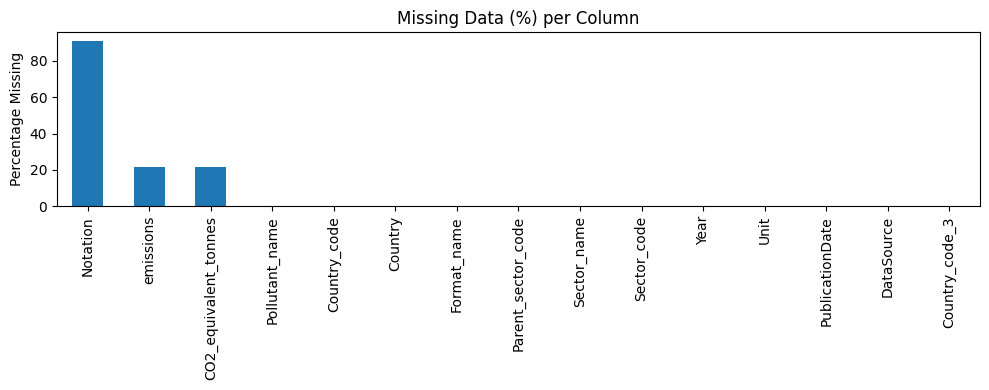


=== Outlier Detection (IQR Rule) ===
                       Outlier Count  Outlier %
Year                             0.0       0.00
emissions                       81.0      16.07
PublicationDate                  0.0       0.00
CO2_equivalent_tonnes           81.0      16.07


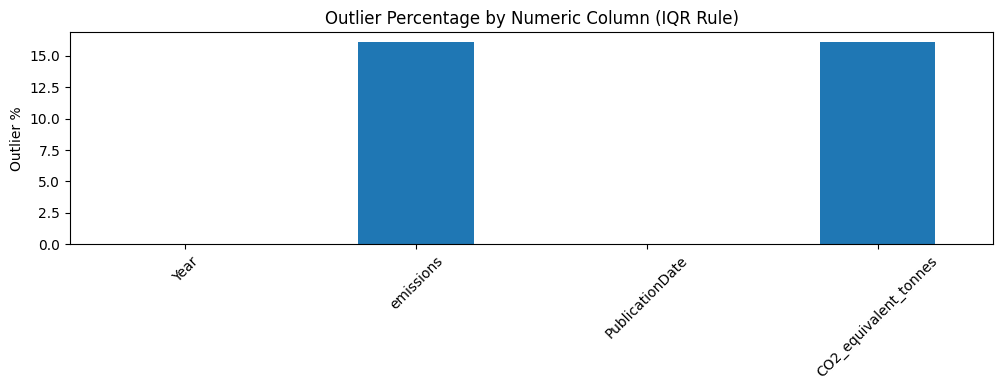

In [ ]:
# ===== MISSINGNESS =====

missing_pct = df_ireland_sectors.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = df_ireland_sectors.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(df_ireland_sectors))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Drop rows where 'emissions' is NaN
df_ireland_sectors = df_ireland_sectors.dropna(subset=['emissions'])

# Reset index after dropping
df_ireland_sectors = df_ireland_sectors.reset_index(drop=True)

# Verifying if missingness is gone
print("Missing % after cleaning:")
print(df_ireland_sectors.isnull().mean() * 100)

Missing % after cleaning:
Country_code               0.0
Country                    0.0
Format_name                0.0
Pollutant_name             0.0
Sector_code                0.0
Sector_name                0.0
Parent_sector_code         0.0
Unit                       0.0
Year                       0.0
emissions                  0.0
Notation                 100.0
PublicationDate            0.0
DataSource                 0.0
Country_code_3             0.0
CO2_equivalent_tonnes      0.0
dtype: float64


In [ ]:
df_ireland_sectors

,Country_code,Country,Format_name,Pollutant_name,Sector_code,Sector_name,Parent_sector_code,Unit,Year,emissions,Notation,PublicationDate,DataSource,Country_code_3,CO2_equivalent_tonnes
0,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2016,38370.50025,NaN,20250315,EEA,IRL,38370500.25
1,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2018,36749.85912,NaN,20250315,EEA,IRL,36749859.12
2,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1,1 - Energy,Sectors/Totals_incl_incl,Gg CO2 equivalent,2021,34887.38467,NaN,20250315,EEA,IRL,34887384.67
3,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1.A.2.e,"1.A.2.e - Food Processing, Beverages and Tobacco",1.A.2,Gg CO2 equivalent,2021,1082.92791,NaN,20250315,EEA,IRL,1082927.91
4,IE,Ireland,IPCC Common Reporting Format,All greenhouse gases - (CO2 equivalent),1.A.4,1.A.4 - Other Sectors,1.AA,Gg CO2 equivalent,2016,9087.57912,NaN,20250315,EEA,IRL,9087579.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,IE,Ireland,IPCC Common Reporting Format,N₂O,3,3 - Agriculture,Sectors/Totals_incl_incl,Gg,2023,16.47716,NaN,20250315,EEA,IRL,16477.16
392,IE,Ireland,IPCC Common Reporting Format,N₂O,5.B.1,5.B.1 - Waste Composting,5.B,Gg,2016,0.05482,NaN,20250315,EEA,IRL,54.82
393,IE,Ireland,IPCC Common Reporting Format,N₂O,5.B.1,5.B.1 - Waste Composting,5.B,Gg,2023,0.06217,NaN,20250315,EEA,IRL,62.17
394,IE,Ireland,IPCC Common Reporting Format,N₂O,5.C.2,5.C.2 - Open Burning of Waste,5.C,Gg,2018,0.00015,NaN,20250315,EEA,IRL,0.15


In [ ]:
columns_to_keep = ['Sector_name', 'Year', 'CO2_equivalent_tonnes']
final_eea_df = df_ireland_sectors[columns_to_keep]
final_eea_df

,Sector_name,Year,CO2_equivalent_tonnes
0,1 - Energy,2016,38370500.25
1,1 - Energy,2018,36749859.12
2,1 - Energy,2021,34887384.67
3,"1.A.2.e - Food Processing, Beverages and Tobacco",2021,1082927.91
4,1.A.4 - Other Sectors,2016,9087579.12
...,...,...,...
391,3 - Agriculture,2023,16477.16
392,5.B.1 - Waste Composting,2016,54.82
393,5.B.1 - Waste Composting,2023,62.17
394,5.C.2 - Open Burning of Waste,2018,0.15


In [ ]:
final_eea_df.to_excel("EEA_Ireland_emissions_data.xlsx")

In [ ]:
EEAdata.nunique()

,0
Country_code,31
Country,31
Format_name,1
Pollutant_name,9
Sector_code,166
Sector_name,166
Parent_sector_code,40
Unit,2
Year,34
emissions,256999


###FAO Annual Population

In [ ]:
FAOdata1 = pd.read_csv("/content/drive/MyDrive/Projects/IS6051 Business Data Analysis and Visualization/Datasets/FAOStat_Annual_Population.csv")
FAOdata1.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,OA,Annual population,372,Ireland,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1950,1950,1000 No,2912.654,X,Figure from external organization,NaN
1,OA,Annual population,372,Ireland,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1951,1951,1000 No,2936.864,X,Figure from external organization,NaN
2,OA,Annual population,372,Ireland,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1952,1952,1000 No,2941.463,X,Figure from external organization,NaN
3,OA,Annual population,372,Ireland,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1953,1953,1000 No,2929.081,X,Figure from external organization,NaN
4,OA,Annual population,372,Ireland,511,Total Population - Both sexes,3010,Population - Est. & Proj.,1954,1954,1000 No,2915.173,X,Figure from external organization,NaN


In [ ]:
FAOdata1.describe()

,Area Code (M49),Element Code,Item Code,Year Code,Year,Value,Note
count,74.0,74.0,74.0,74.000000,74.000000,74.000000,0.0
mean,372.0,511.0,3010.0,1986.500000,1986.500000,3639.984608,NaN
std,0.0,0.0,0.0,21.505813,21.505813,714.860842,NaN
min,372.0,511.0,3010.0,1950.000000,1950.000000,2824.693000,NaN
25%,372.0,511.0,3010.0,1968.250000,1968.250000,2940.930500,NaN
50%,372.0,511.0,3010.0,1986.500000,1986.500000,3520.524500,NaN
75%,372.0,511.0,3010.0,2004.750000,2004.750000,4132.979000,NaN
max,372.0,511.0,3010.0,2023.000000,2023.000000,5196.630000,NaN


Missing Percentage 
  Domain Code           0.0
Domain                0.0
Area Code (M49)       0.0
Area                  0.0
Element Code          0.0
Element               0.0
Item Code             0.0
Item                  0.0
Year Code             0.0
Year                  0.0
Unit                  0.0
Value                 0.0
Flag                  0.0
Flag Description      0.0
Note                100.0
dtype: float64


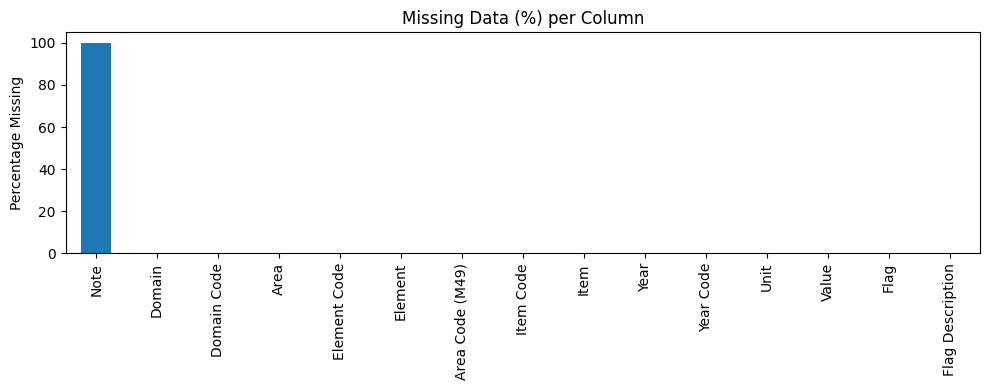


=== Outlier Detection (IQR Rule) ===
                 Outlier Count  Outlier %
Area Code (M49)            0.0        0.0
Element Code               0.0        0.0
Item Code                  0.0        0.0
Year Code                  0.0        0.0
Year                       0.0        0.0
Value                      0.0        0.0
Note                       0.0        0.0


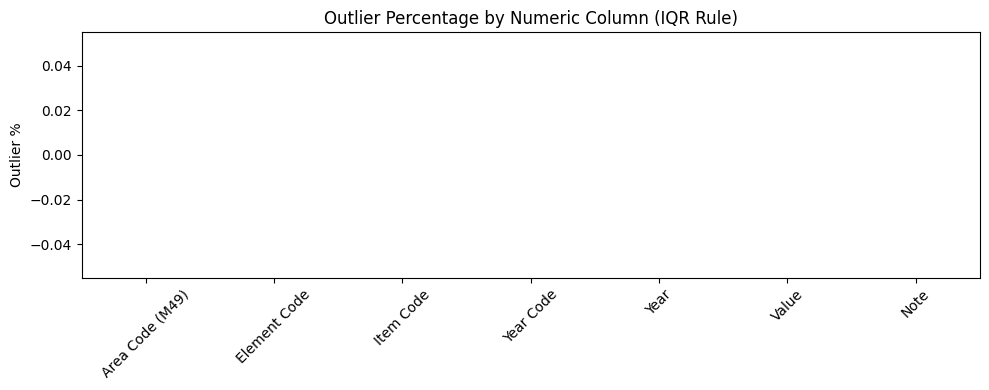

In [ ]:
# ===== MISSINGNESS =====

missing_pct = FAOdata1.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = FAOdata1.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(FAOdata1))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
columns_to_keep = ['Year', 'Unit', 'Value']
FAOdata1_filtered = FAOdata1[columns_to_keep]
FAOdata1_filtered.head()

,Year,Unit,Value
0,1950,1000 No,2912.654
1,1951,1000 No,2936.864
2,1952,1000 No,2941.463
3,1953,1000 No,2929.081
4,1954,1000 No,2915.173


In [ ]:
columns_to_keep = ['Year', 'Unit', 'Value']
FAOdata1_processed = FAOdata1[columns_to_keep].copy()

# Convert 'Value' to numeric if not already
FAOdata1_processed['Value'] = pd.to_numeric(FAOdata1_processed['Value'], errors='coerce')

# Creating the 'Population' column by multiplying 'Value' by 1000
FAOdata1_processed['Population'] = FAOdata1_processed['Value'] * 1000

FAOdata1_processed.head()

,Year,Unit,Value,Population
0,1950,1000 No,2912.654,2912654.0
1,1951,1000 No,2936.864,2936864.0
2,1952,1000 No,2941.463,2941463.0
3,1953,1000 No,2929.081,2929081.0
4,1954,1000 No,2915.173,2915173.0


In [ ]:
final_cols = ['Year', 'Population']
FAO_final = FAOdata1_processed[final_cols].copy()
FAO_final.to_excel("FAO_Annual_Population.xlsx")

In [ ]:
# Drop 'Unit' and 'Value' from FAO data
FAOdata1_processed = FAOdata1_processed.drop(columns=['Unit', 'Value'])

# Merge with df_long on 'Year'
# Using 'left' join to keep all years in df_long (e.g., 2015–2022)
merged_df = pd.merge(
    df_long,
    FAOdata1_processed,
    on='Year',
    how='left'
)

# Verify the result
print("Merged DataFrame columns:")
print(merged_df.columns.tolist())
print("\nMissing Population values (if any):")
print(merged_df['Population'].isnull().sum())



Merged DataFrame columns:
['Year', 'Total_t', 'Sector', 'Value_tonnes', 'Population']

Missing Population values (if any):
0


In [ ]:
# Create food_waste_per_capita (kg per person)
merged_df['food_waste_per_capita'] = (merged_df['Total_t'] / merged_df['Population']) * 1000

# Round to 2 decimal places for readability
merged_df['food_waste_per_capita'] = merged_df['food_waste_per_capita'].round(2)


In [ ]:
merged_df

,Year,Total_t,Sector,Value_tonnes,Population,food_waste_per_capita
0,2015,1053700.0,Commercial,801200.0,4702487.0,224.07
1,2015,1053700.0,Households,252500.0,4702487.0,224.07
2,2016,1053700.0,Commercial,801200.0,4753503.0,221.67
3,2016,1053700.0,Households,252500.0,4753503.0,221.67
4,2017,1053700.0,Commercial,801200.0,4810261.0,219.05
5,2017,1053700.0,Households,252500.0,4810261.0,219.05
6,2018,1053700.0,Commercial,801200.0,4872556.0,216.25
7,2018,1053700.0,Households,252500.0,4872556.0,216.25
8,2019,1100020.0,Commercial,845275.0,4933491.0,222.97
9,2019,1100020.0,Households,254745.0,4933491.0,222.97


In [ ]:
merged_df.to_csv("food_waste_per_capita.csv")

###FAO Food Production Indices

In [ ]:
FAOdata2 = pd.read_csv("/content/drive/MyDrive/Projects/IS6051 Business Data Analysis and Visualization/Datasets/FAOStat_Food_Production_Indices.csv")
FAOdata2.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description
0,QI,Production Indices,372,Ireland,432,Gross Production Index Number (2014-2016 = 100),01341,Apples,1961,1961,NaN,144.52,E,Estimated value
1,QI,Production Indices,372,Ireland,432,Gross Production Index Number (2014-2016 = 100),01341,Apples,1962,1962,NaN,154.49,E,Estimated value
2,QI,Production Indices,372,Ireland,432,Gross Production Index Number (2014-2016 = 100),01341,Apples,1963,1963,NaN,174.42,E,Estimated value
3,QI,Production Indices,372,Ireland,432,Gross Production Index Number (2014-2016 = 100),01341,Apples,1964,1964,NaN,119.60,E,Estimated value
4,QI,Production Indices,372,Ireland,432,Gross Production Index Number (2014-2016 = 100),01341,Apples,1965,1965,NaN,104.65,E,Estimated value


In [ ]:
FAOdata2.describe()

,Area Code (M49),Element Code,Year Code,Year,Unit,Value
count,4666.0,4666.000000,4666.000000,4666.000000,0.0,4666.000000
mean,372.0,433.000000,1992.417917,1992.417917,NaN,205.943311
std,0.0,1.000107,17.128723,17.128723,NaN,608.301323
min,372.0,432.000000,1961.000000,1961.000000,NaN,0.830000
25%,372.0,432.000000,1978.000000,1978.000000,NaN,70.252500
50%,372.0,433.000000,1993.000000,1993.000000,NaN,96.160000
75%,372.0,434.000000,2007.000000,2007.000000,NaN,131.292500
max,372.0,434.000000,2023.000000,2023.000000,NaN,14480.680000


Missing Percentage 
  Domain Code           0.0
Domain                0.0
Area Code (M49)       0.0
Area                  0.0
Element Code          0.0
Element               0.0
Item Code (CPC)       0.0
Item                  0.0
Year Code             0.0
Year                  0.0
Unit                100.0
Value                 0.0
Flag                  0.0
Flag Description      0.0
dtype: float64


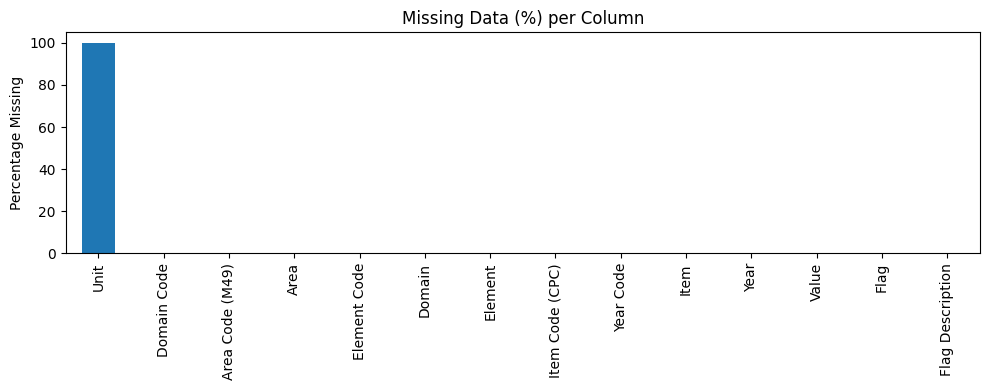


=== Outlier Detection (IQR Rule) ===
                 Outlier Count  Outlier %
Area Code (M49)            0.0       0.00
Element Code               0.0       0.00
Year Code                  0.0       0.00
Year                       0.0       0.00
Unit                       0.0       0.00
Value                    617.0      13.22


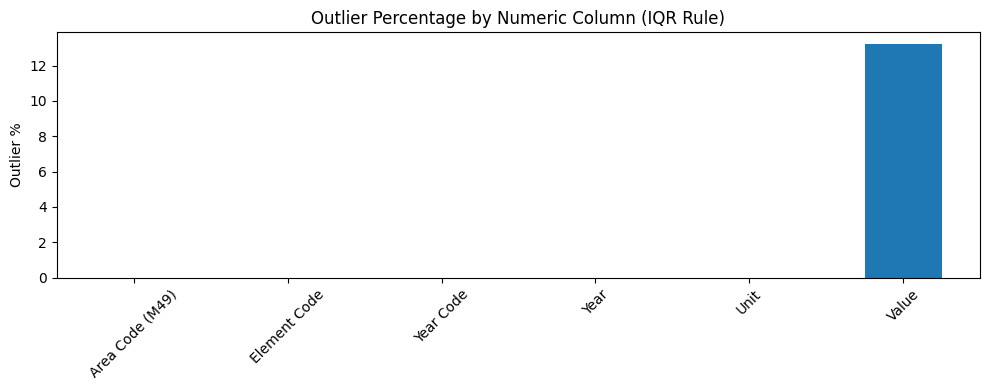

In [ ]:
# ===== MISSINGNESS =====

missing_pct = FAOdata2.isna().mean() * 100
print("Missing Percentage \n ",missing_pct)
missing_pct.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title("Missing Data (%) per Column")
plt.ylabel("Percentage Missing")
plt.tight_layout()
plt.show()


# ===== SIMPLE OUTLIER DETECTION (IQR Method) =====
numeric_cols = FAOdata2.select_dtypes(include=[np.number])

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = numeric_cols[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = numeric_cols[(numeric_cols[col] < lower) | (numeric_cols[col] > upper)][col]

    outlier_summary[col] = {
        "Outlier Count": outliers.count(),
        "Outlier %": round((outliers.count()/len(FAOdata2))*100, 2)
    }

print("\n=== Outlier Detection (IQR Rule) ===")
outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

# ===== Simple Visual =====
outlier_df["Outlier %"].plot(kind='bar', figsize=(10,4))
plt.title("Outlier Percentage by Numeric Column (IQR Rule)")
plt.ylabel("Outlier %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
FAOdata2.nunique()

,0
Domain Code,1
Domain,1
Area Code (M49),1
Area,1
Element Code,2
Element,2
Item Code (CPC),43
Item,43
Year Code,63
Year,63


In [ ]:
columns_to_keep = ['Element', 'Year', 'Value']
FAOdata1_filtered_elements = FAOdata1[columns_to_keep]
FAOdata1_filtered_elements.head()

,Element,Year,Value
0,Gross Production Index Number (2014-2016 = 100),1961,144.52
1,Gross Production Index Number (2014-2016 = 100),1962,154.49
2,Gross Production Index Number (2014-2016 = 100),1963,174.42
3,Gross Production Index Number (2014-2016 = 100),1964,119.60
4,Gross Production Index Number (2014-2016 = 100),1965,104.65


##Basic Visuals Executed in Python before using in Dashboard

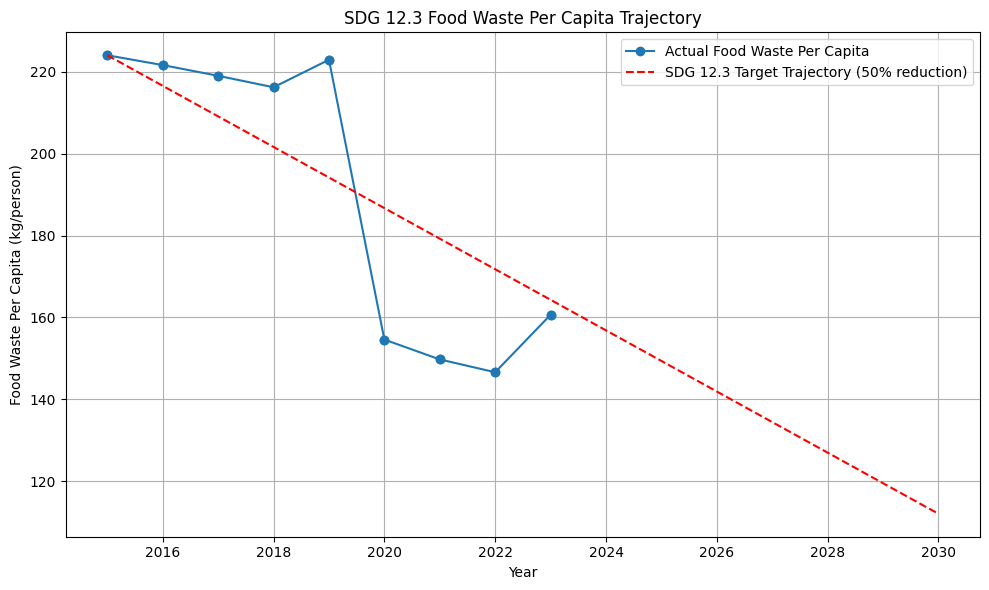

In [ ]:
# Define baseline (2015) and target reduction by 2030
baseline_year = 2015
target_year = 2030
reduction_fraction = 0.5  # 50% reduction target

baseline_value = merged_df.loc[merged_df['Year'] == baseline_year, 'food_waste_per_capita'].values[0]
target_value = baseline_value * (1 - reduction_fraction)

# Generate linear trajectory for 2015-2030
trajectory_years = np.arange(baseline_year, target_year + 1)
trajectory_values = baseline_value - ((trajectory_years - baseline_year) / (target_year - baseline_year)) * (baseline_value - target_value)

# Plot
plt.figure(figsize=(10,6))
plt.plot(merged_df['Year'], merged_df['food_waste_per_capita'], marker='o', label='Actual Food Waste Per Capita')
plt.plot(trajectory_years, trajectory_values, linestyle='--', color='red', label='SDG 12.3 Target Trajectory (50% reduction)')

plt.xlabel('Year')
plt.ylabel('Food Waste Per Capita (kg/person)')
plt.title('SDG 12.3 Food Waste Per Capita Trajectory')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()